In [76]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

<Axes: xlabel='SI', ylabel='Count'>

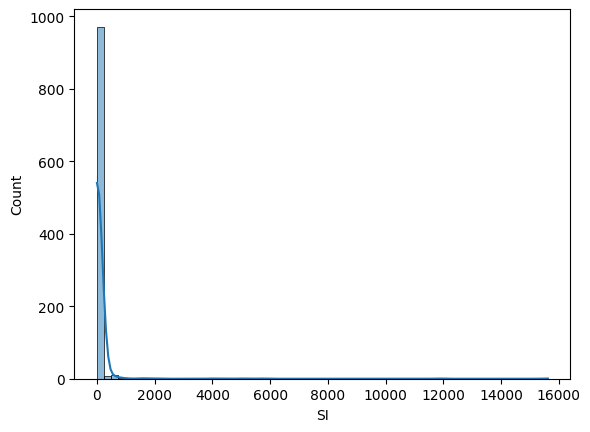

In [94]:
# загрузка данных
X = pd.read_excel('X_data.xlsx')
df_y = pd.read_excel('Y_data.xlsx')   
y = df_y['SI'] 

# визуализация распределения целевой переменной
sns.histplot(y, kde=True)

Распределение SI характеризуется выраженной правосторонней асимметрией и наличием экстремально больших значений, поэтому дополнительно возможно целесообразно применить логарифмическую трансформацию целевой переменной.

In [95]:
# Линейная регрессия для предсказания SI на основе молекулярных дескрипторов до логарифмирования целевой переменной
# разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# стандартизация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# обучение модели линейной регрессии        
model = LinearRegression()
model.fit(X_train, y_train)     

# предсказание на тестовой выборке
y_pred = model.predict(X_test)  

# оценка качества модели
mse = mean_squared_error(y_test, y_pred)    
r2 = r2_score(y_test, y_pred)

print('Линейная регрессия для предсказания исходного SI на основе молекулярных дескрипторов:')
print(f'Mean Squared Error: {mse:.2f}') 
print(f'R^2 Score: {r2:.2f}')           


Линейная регрессия для предсказания исходного SI на основе молекулярных дескрипторов:
Mean Squared Error: 1874508.21
R^2 Score: 0.07


In [96]:
# Lasso-регрессия для предсказания SI на основе молекулярных дескрипторов до логарифмирования целевой переменной

# обучение модели Lasso-регрессии
lasso_model_raw = Lasso(alpha=0.1, max_iter=50000)      
lasso_model_raw.fit(X_train, y_train)

# предсказание на тестовой выборке
y_pred_lasso = lasso_model_raw.predict(X_test)

# оценка качества модели Lasso-регрессии
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print('Lasso-регрессия для предсказания исходного SI на основе молекулярных дескрипторов:')
print(f'Lasso Mean Squared Error: {mse_lasso:.2f}')
print(f'Lasso R^2 Score: {r2_lasso:.2f}')

Lasso-регрессия для предсказания исходного SI на основе молекулярных дескрипторов:
Lasso Mean Squared Error: 1874806.19
Lasso R^2 Score: 0.07


In [57]:
# подбор оптимального значения параметра регуляризации alpha с помощью кросс-валидации
model = LassoCV(
    cv=5,
    random_state=42,
    max_iter=50000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Оптимальное значение alpha и оценка качества модели:')
print(model.alpha_.round(4))
print(f'R^2 Score: {r2_score(y_test, y_pred):.2f}')

Оптимальное значение alpha и оценка качества модели:
3.8636
R^2 Score: 0.04


In [97]:
# Lasso регрессия с оптимальным alpha 3.8636

# обучение модели Lasso-регрессии с оптимальным alpha
lasso_model_optimal= Lasso(alpha=3.8636, max_iter=50000)      
lasso_model_optimal.fit(X_train, y_train)

# предсказание на тестовой выборке
y_pred_lasso = lasso_model_optimal.predict(X_test)

# оценка качества модели Lasso-регрессии
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print('Lasso-регрессия с оптимальным alpha 3.8636 для предсказания исходного SI на основе молекулярных дескрипторов:')
print(f'Lasso Mean Squared Error: {mse_lasso:.2f}')
print(f'Lasso R^2 Score: {r2_lasso:.2f}')

Lasso-регрессия с оптимальным alpha 3.8636 для предсказания исходного SI на основе молекулярных дескрипторов:
Lasso Mean Squared Error: 1931383.90
Lasso R^2 Score: 0.04


<Axes: xlabel='log_SI', ylabel='Count'>

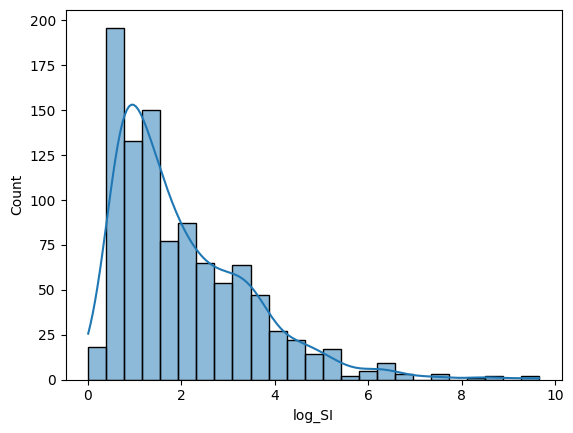

In [99]:
# логарифмирование целевой переменной CC50 для улучшения распределения и повышения точности модели
df_y['log_SI'] = np.log1p(df_y['SI'])

# визуализация распределения целевой переменной после логарифмирования
sns.histplot(df_y['log_SI'], kde=True)

In [100]:
# Линейная регрессия для предсказания логарифмированного SI на основе молекулярных дескрипторов
y= df_y['log_SI']

# разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# стандартизация данных
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# обучение модели линейной регрессии        
model = LinearRegression()
model.fit(X_train, y_train)    
 
# предсказание на тестовой выборке
y_pred = model.predict(X_test)  

# оценка качества модели
mse = mean_squared_error(y_test, y_pred)    
r2 = r2_score(y_test, y_pred)

print('Линейная регрессия для предсказания логарифмированного SI на основе молекулярных дескрипторов:')
print(f'Mean Squared Error: {mse:.2f}') 
print(f'R^2 Score: {r2:.2f}')    

Линейная регрессия для предсказания логарифмированного SI на основе молекулярных дескрипторов:
Mean Squared Error: 2.85
R^2 Score: -0.08


In [101]:
# Lasso регрессия для предсказания логарифмированного SI на основе молекулярных дескрипторов

# обучение модели Lasso-регрессии
lasso_model = Lasso(alpha=0.1, max_iter=50000)      
lasso_model.fit(X_train, y_train)

# предсказание на тестовой выборке
y_pred_lasso = lasso_model.predict(X_test)

# оценка качества модели Lasso-регрессии
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print('Lasso регрессия для предсказания логарифмированного SI на основе молекулярных дескрипторов:')
print(f'Lasso Mean Squared Error: {mse_lasso:.2f}')
print(f'Lasso R^2 Score: {r2_lasso:.2f}')

Lasso регрессия для предсказания логарифмированного SI на основе молекулярных дескрипторов:
Lasso Mean Squared Error: 2.41
Lasso R^2 Score: 0.09


In [102]:
# подбор оптимального значения параметра регуляризации alpha с помощью кросс-валидации

model = LassoCV(
    cv=5,
    random_state=42,
    max_iter=50000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Оптимальное значение alpha и оценка качества модели:')
print(model.alpha_.round(4))
print(f'R^2 Score: {r2_score(y_test, y_pred):.2f}')

Оптимальное значение alpha и оценка качества модели:
0.0187
R^2 Score: 0.18


In [106]:
# Lasso регрессия с оптимальным alpha 0.0187

# обучение модели Lasso-регрессии с оптимальным alpha
lasso_model_optimal = Lasso(alpha=0.0187)      
lasso_model_optimal.fit(X_train, y_train)

# предсказание на тестовой выборке
y_pred_lasso = lasso_model_optimal.predict(X_test)

# оценка качества модели Lasso-регрессии
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print('Lasso-регрессия с оптимальным alpha 0.0187 для предсказания логарифмированного SI на основе молекулярных дескрипторов:')
print(f'Lasso Mean Squared Error: {mse_lasso:.2f}')
print(f'Lasso R^2 Score: {r2_lasso:.2f}')

Lasso-регрессия с оптимальным alpha 0.0187 для предсказания логарифмированного SI на основе молекулярных дескрипторов:
Lasso Mean Squared Error: 2.18
Lasso R^2 Score: 0.18


In [107]:
# анализ коэффициентов Lasso-регрессии
print(np.sum(lasso_model_optimal.coef_ != 0))
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_model_optimal.coef_
})

coef_df = coef_df[coef_df['Coefficient'] != 0]

coef_df.sort_values(by='Coefficient', ascending=False)

56


,Feature,Coefficient
104,fr_Imine,0.280880
14,BCUT2D_LOGPHI,0.236178
24,Kappa3,0.201048
96,fr_Al_COO,0.185114
7,FpDensityMorgan1,0.141025
32,PEOE_VSA3,0.134536
122,fr_imidazole,0.115929
106,fr_NH1,0.114473
48,SlogP_VSA1,0.106028
142,fr_unbrch_alkane,0.104964


<Axes: title={'center': 'Коэффициенты Lasso-регрессии после логарифмирования целевой переменной'}, ylabel='Feature'>

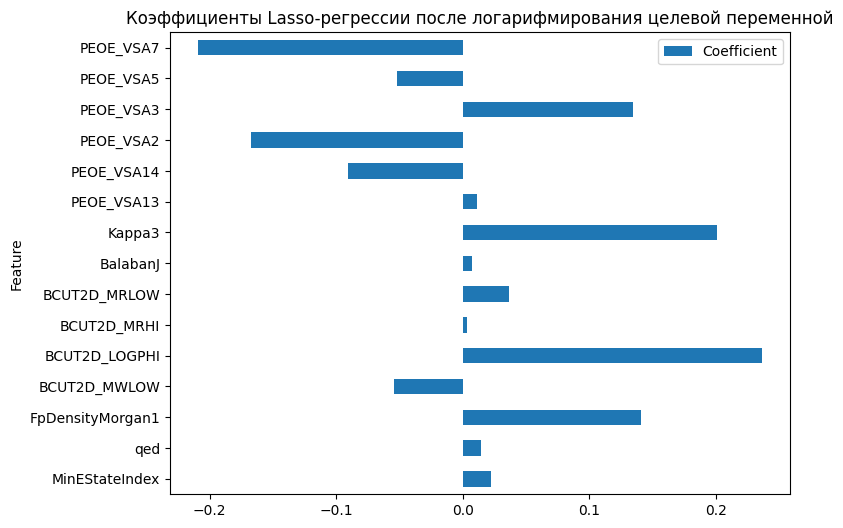

In [70]:
# визуализация коэффициентов Lasso-регрессии после логарифмирования целевой переменной
coef_df.head(15).plot.barh(
    x='Feature',
    y='Coefficient',
    figsize=(8,6),
    title='Коэффициенты Lasso-регрессии после логарифмирования целевой переменной'
)

##### Вывод:

Для прогнозирования SI были исследованы линейная регрессия и Lasso-регрессия как на исходных, так и на логарифмированных значениях целевой переменной.
На исходных данных линейные модели показали крайне низкое качество прогнозирования (R² ≈ 0.04–0.07), что свидетельствует о высокой сложности зависимости между молекулярными дескрипторами и значениями SI. 
Распределение SI характеризовалось выраженной правосторонней асимметрией и наличием экстремально больших значений, поэтому дополнительно была применена логарифмическая трансформация целевой переменной. После логарифмирования распределение SI стало более симметричным, а влияние экстремальных значений уменьшилось. Это позволило улучшить качество Lasso-регрессии после подбора оптимального параметра регуляризации (alpha = 0.0187) до R² ≈ 0.18.

Несмотря на улучшение качества после логарифмирования, линейные модели по-прежнему показали низкую способность к прогнозированию SI. Это может быть связано с тем, что SI является производной характеристикой, одновременно зависящей от IC50 и CC50, и содержит высокий уровень шума и сложных нелинейных зависимостей.

In [108]:
# Decision Tree Regressor для предсказания логарифмированное значение SI на основе молекулярных дескрипторов

y= df_y['log_SI']  # Используем логарифмированное значение SI для регрессии

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создание и обучение модели
max_depth = [3, 5, 7, 10]

for depth in max_depth:
    model = DecisionTreeRegressor(criterion='squared_error', max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    # Предсказание на тестовой выборке
    y_pred = model.predict(X_test)

    # Оценка качества модели
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f'Decision Tree Regressor (max_depth={depth}) для предсказания исходного SI на основе молекулярных дескрипторов:')
    print(f'Среднеквадратичная ошибка: {mse:.2f}')
    print(f'R²: {r2:.2f}')

Decision Tree Regressor (max_depth=3) для предсказания исходного SI на основе молекулярных дескрипторов:
Среднеквадратичная ошибка: 2.04
R²: 0.23
Decision Tree Regressor (max_depth=5) для предсказания исходного SI на основе молекулярных дескрипторов:
Среднеквадратичная ошибка: 1.87
R²: 0.29
Decision Tree Regressor (max_depth=7) для предсказания исходного SI на основе молекулярных дескрипторов:
Среднеквадратичная ошибка: 1.82
R²: 0.31
Decision Tree Regressor (max_depth=10) для предсказания исходного SI на основе молекулярных дескрипторов:
Среднеквадратичная ошибка: 1.88
R²: 0.29


In [109]:
# Random Forest Regressor для предсказания исходного SI на основе молекулярных дескрипторов

# обучение модели случайного леса с подбором гиперпараметров с помощью RandomizedSearchCV
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=50,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV R²:", search.best_score_)

# лучшая модель случайного леса
best_rf = search.best_estimator_

# предсказание на тестовой выборке
y_pred = best_rf.predict(X_test)

print('Random Forest Regressor для предсказания исходного SI на основе молекулярных дескрипторов:')
print(f"mse: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.2f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': False}
Best CV R²: 0.31861832186660294
Random Forest Regressor для предсказания исходного SI на основе молекулярных дескрипторов:
mse: 1.68
R²: 0.37


В отличие от прогнозирования исходных значений SI, логарифмирование целевой переменной существенно улучшило качество нелинейных моделей. Наилучший результат показал RandomForestRegressor (R² ≈ 0.37), что свидетельствует о высокой важности стабилизации распределения целевой переменной при прогнозировании SI.

<Axes: title={'center': 'Важность признаков после обучения случайного леса'}, ylabel='Feature'>

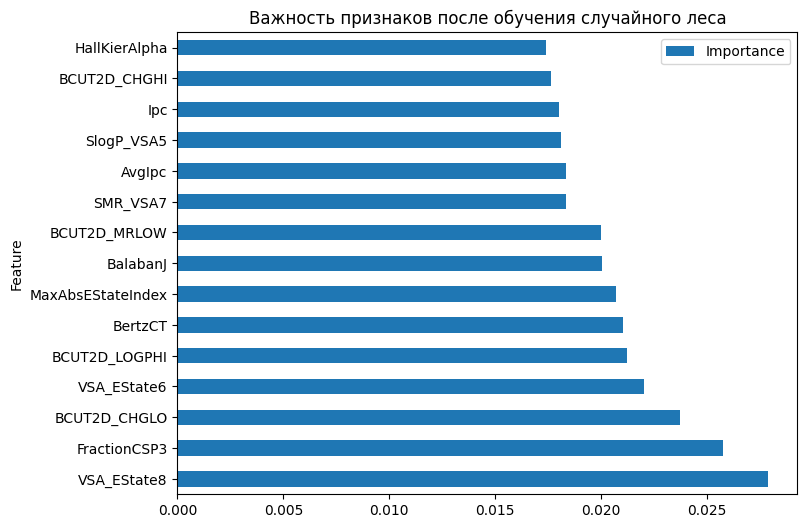

In [84]:
# визуализация важности признаков после обучения случайного леса
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df.head(15).plot.barh(
    x='Feature',
    y='Importance',
    figsize=(8,6),
    title='Важность признаков после обучения случайного леса')

Анализ важности признаков RandomForestRegressor после логарифмирования SI показал, что наибольший вклад в прогнозирование селективности соединений вносят дескрипторы, характеризующие электронные свойства, топологию, пространственную структуру и физико-химические характеристики молекул.
Среди наиболее значимых признаков модель выделила VSA_EState8, FractionCSP3, BCUT2D_CHGLO, VSA_EState6, BCUT2D_LOGPHI, BertzCT и MaxAbsEStateIndex. Это указывает на важную роль распределения электронной плотности, липофильности, сложности молекулярной структуры и пространственной организации молек

In [90]:
# CatBoost Regressor для предсказания исходного SI на основе молекулярных дескрипторов
# обучение модели CatBoost Regressor
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_state=42,
    verbose=0
)

model.fit(X_train, y_train)

# предсказание на тестовой выборке
y_pred = model.predict(X_test)

print('CatBoost Regressor для предсказания исходного SI на основе молекулярных дескрипторов:')
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.2f}")

CatBoost Regressor для предсказания исходного SI на основе молекулярных дескрипторов:
MSE: 1.71
R²: 0.36


In [91]:
# SVR для предсказания для предсказания логарифмированного SI на основе молекулярных дескрипторов

y= df_y['log_SI']

# стандартизация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Создание и обучение модели
model_svr = SVR(kernel='rbf', C=1, gamma='scale')
model_svr.fit(X_train, y_train)

y_pred = model_svr.predict(X_test)


print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 1.8880366656000698
R²: 0.286956667459214


In [111]:
# Настройка гиперпараметров для SVR  с использованием GridSearchCV

# Cоздание пайплайна для стандартизации данных и обучения модели SVR
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf'))
])

# Настройка гиперпараметров для SVR с использованием GridSearchCV
param_grid = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__gamma': ['scale', 0.1, 0.01, 0.001],
    'svr__epsilon': [0.01, 0.1, 0.5]
}

# Настройка GridSearchCV для поиска оптимальных гиперпараметров
grid = GridSearchCV(
    pipe,
    param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

# обучение модели с использованием GridSearchCV
grid.fit(X_train, y_train)

# предсказание на тестовой выборке с использованием оптимальных гиперпараметров
y_pred = grid.predict(X_test)

# оценка качества модели с использованием оптимальных гиперпараметров
print("Best params:",grid.best_params_)
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.2f}")

Best params: {'svr__C': 1, 'svr__epsilon': 0.1, 'svr__gamma': 0.01}
MSE: 1.81
R²: 0.32


#### Вывод:

Для прогнозирования SI были исследованы линейные и нелинейные модели регрессии как на исходных, так и на логарифмированных значениях целевой переменной.

На исходных данных все модели показали крайне низкое качество прогнозирования (R² ≈ 0.04–0.10), что свидетельствовало о высокой сложности зависимости между молекулярными дескрипторами и значениями SI.

Распределение SI характеризовалось выраженной правосторонней асимметрией и наличием экстремально больших значений, поэтому была применена логарифмическая трансформация целевой переменной.

После логарифмирования качество нелинейных моделей существенно улучшилось. Наилучший результат показал RandomForestRegressor (R² ≈ 0.37), близкие результаты также продемонстрировали CatBoostRegressor (R² ≈ 0.36) и SVR (R² ≈ 0.32).

Полученные результаты свидетельствуют о том, что для прогнозирования SI особенно важны стабилизация распределения целевой переменной и использование нелинейных методов машинного обучения.

При этом линейные модели (Linear Regression, Lasso) даже после логарифмирования показали ограниченную способность описывать зависимость между молекулярными дескрипторами и селективностью соединений.

Полученные результаты подтверждают наличие сложных нелинейных закономерностей при прогнозировании SI, а также высокую чувствительность данной характеристики к выбросам и экстремальным значениям:

